In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [35]:
# Importem llibreries:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, make_scorer
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBClassifier


In [4]:
# Carreguem el dataset:
os.getcwd() #'C:\\Users\\paugr\\OneDrive\\Desktop\\PROJECT_TFM\\notebooks'

df = pd.read_csv('C:\\Users\\paugr\\OneDrive\\Desktop\\PROJECT_TFM\\data\\data.csv')
df.head()


,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
0,0387DD8A07E07FDA6271170F86AD9151,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.12,9.96,16.92,7.60,27.22,18.05,26.47,18.75,17.84,14.92
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B32AC8CC6D5D805AC053557AB05F5343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.50,9.99,11.78,18.59,26.80,18.57,14.59,12.82,19.37,15.92
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,3.42,3.81,4.58,3.56,4.25,3.86,3.53,...,17.77,10.37,15.32,13.51,12.23,14.68,16.35,18.14,18.41,17.31


## Preprocessament del Dataset

In [5]:
print("Informació general del dataset:\n")
df.info()

print("Descripció del dataset:\n")
df.describe()

Informació general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42372 entries, 0 to 42371
Columns: 1036 entries, CONS_NO to 2016/9/9
dtypes: float64(1034), int64(1), object(1)
memory usage: 334.9+ MB
Descripció del dataset:



,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,2014/1/17,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
count,42372.000000,25870.000000,25912.000000,25911.000000,25912.00000,25912.000000,25912.000000,25915.000000,25924.000000,25925.000000,...,40544.000000,41482.000000,41915.000000,41151.000000,41906.000000,41873.000000,41850.000000,41967.000000,42044.000000,42027.00000
mean,0.085316,7.168735,6.954202,6.784099,7.08430,10.516470,7.219633,7.341512,7.160004,6.839875,...,8.836129,9.304656,10.758718,9.942215,11.173498,11.482926,11.656425,11.322680,11.015589,10.69165
std,0.279354,34.131237,40.017856,38.327058,31.98716,576.388348,34.703617,36.569049,36.916957,30.235396,...,52.371956,57.063621,88.039832,62.010381,94.267851,100.971180,118.369381,103.891111,100.614909,107.25814
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.660000,0.820000,0.880000,0.880000,0.900000,0.920000,0.940000,0.910000,0.910000,0.90000
50%,0.000000,3.310000,2.870000,2.900000,3.35000,3.440000,3.295000,3.470000,3.130000,3.250000,...,4.380000,4.670000,5.010000,4.820000,5.150000,5.110000,5.190000,5.110000,5.020000,4.93000
75%,0.000000,8.910000,8.170000,8.210000,8.76000,8.620000,8.740000,8.900000,8.780000,8.520000,...,9.300000,9.380000,10.740000,9.700000,11.380000,11.430000,11.600000,11.300000,10.730000,10.28000
max,1.000000,3318.000000,3966.000000,4392.000000,3414.00000,92713.900000,3167.000000,3960.000000,3654.000000,3306.000000,...,6324.000000,6990.000000,14640.000000,6672.000000,16320.000000,17100.000000,21210.000000,17940.000000,16710.000000,18570.00000


Veiem que el dataset conté 42.372 usuaris, cada fila representa un usuari i una contrasenya. Hi ha 1036 columnes, la columna 1 és CONS_NO, un identificador del client, la columna 2 és FLAG, que val 0 si és legal i 1 si és fraudulent.

In [6]:
# Observem el desequilibri entre classes:
df['FLAG'].value_counts(normalize=True) # Ho mostrem en percentatge.

FLAG
0    0.914684
1    0.085316
Name: proportion, dtype: float64

Podem veure com, efectivament, el dataset està altament desequilibrat. Un 91.4% dels registres es corresponen a dades de consum lícit, mentre que un 8.5% es corresponen a frau. Més endavant farem servir estratègies per a minimitzar l'impacte d'aquest desequilibri en el desenvolupament d'un model predictiu. 

### Tractament de Valors Perduts

In [7]:
# Percentatge de valor perduts per columna:
missing_prop = df.isna().mean()
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False).head(20)

2014/10/3    99.964599
2014/3/19    50.752856
2014/2/28    49.525630
2014/3/4     49.136222
2014/3/3     49.103181
2014/4/19    48.694893
2014/2/20    48.465968
2014/2/23    48.366846
2014/2/24    47.970358
2014/3/2     47.729633
2014/3/1     47.689512
2014/2/27    47.590390
2014/2/25    47.005098
2014/2/21    46.924856
2014/2/26    46.917776
2014/4/9     46.273482
2014/2/22    46.242802
2015/8/8     45.902955
2014/3/23    45.730671
2014/3/26    45.591428
dtype: float64

Veiem que el dia 3/10/2014 hi ha un 99.96% de valors perduts. Aquesta columna es torna inútil per a modelar, i l'eliminarem del dataset. Farem el mateix amb totes les columnes que tinguin un percentatge de valors perduts superior al 80%. No només això, la bibliografia consultada explica que en el cas d'aquest dataset és més adequat eliminar columnes amb molts NAs ja que aquestes dificulten la imputació de valors.  La resta de NAs els imputarem posteriorment.

In [8]:
# Eliminem columnes amb més del 80% de NAs.
# Percentatge de NAs per columna
na_perc_col = df.isna().mean()

# Eliminem columnes amb massa NAs
cols_to_drop = na_perc_col[na_perc_col > 0.80].index

df_clean = df.drop(columns=cols_to_drop)

print(f"Columnes eliminades: {len(cols_to_drop)}")
print(f"Columnes finals: {df_clean.shape[1]}")

Columnes eliminades: 1
Columnes finals: 1035


També eliminarem files amb % de NAs elevat. Ara bé, cal anar en compte, ja que reduïr de més el dataset pot ser arriscat, i més si tenim en compte la baixa proporció de casos de frau. Per tant, una bona manera de procedir seria eliminant les files amb més del 90% de valors mancants. La resta de NAs els imputarem posteriorment.

In [9]:
# Eliminem files amb més del 90% de NAs. 
# Percentatge de NAs per fila
na_perc_row = df_clean.isna().mean(axis=1)

# Eliminem files amb massa NAs
rows_to_drop = na_perc_row[na_perc_row > 0.90].index

df_clean = df_clean.drop(index=rows_to_drop)

print(f"Files eliminades: {len(rows_to_drop)}")
print(f"Files finals: {df_clean.shape[0]}")

Files eliminades: 80
Files finals: 42292


### Train/Test/Val

In [10]:
# Columnes que no ens interessa tocar:
id_cols = ['CONS_NO']
target_col = 'FLAG'

# Columnes de consum (totes les altres menys ID i target)
feature_cols = [c for c in df_clean.columns if c not in id_cols + [target_col]]

# Separem features i target
X = df_clean[feature_cols]
y = df_clean[target_col]

# La divisió serà 70% train, 15% test i 15% validation
# Primer: train vs temp (temp = validació + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Ara separem temp en validació i test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (29604, 1033)
Validation size: (6344, 1033)
Test size: (6344, 1033)


### Imputació de valors perduts

Per a imputar valors perduts (només sobre el conjunt d'entrenament per a evitar *data leakage*), tenim diverses opcions. Ens podríem plantejar fer servir `KNNImputer`, però al ser una matriu tant gran i amb tantes dimensions, es converteix en un mètode d'imputació inviable. Cal tenir en compte que `KNNImputer` calcula la distància entre cada fila i totes les altres files, i per tant implica una dificultat aproximada de $O(n^2 * d)$, on $n = 42.000$ i $d = 1034$. Ens cal trobar una alternativa més factible. Farem servir `Median imputation`, un mètode simple, prou robust i que funciona especialment bé en datasets de consum. https://www.kaggle.com/code/pagenotfound/mean-and-median-imputation

In [11]:
imputer = SimpleImputer(strategy="median")

df_imputed = df_clean.copy()

# FIT només a TRAIN
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# Reconstruim els Dataframes (per a no treballar amb arrays)
X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)
X_val_imp   = pd.DataFrame(X_val_imp,   columns=X_val.columns,   index=X_val.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=X_test.columns,  index=X_test.index)


# Comprovem que no quedin NAs
print(X_train_imp.isna().sum().sum(), X_val_imp.isna().sum().sum(), X_test_imp.isna().sum().sum())

0 0 0


És important pensar també en els valors outliers. Ara bé, en series temporals de consum pot resultar normal trobar pics, consums anormalment elevats (en caps de setmana, festius o dies puntuals), o els propis comportaments fraudulents. Per tant, es tracta de perdre la mínima informació de cara a detectar aquest comportament fraudulents, i per aquest motiu no eliminarem cap valor atípic de moment. 

### Normalització

A continuació necessitem transformar les variables numèriques per a assegurar-nos de que operem en escales comparables. Això permetrà que els algorítmes no donin més importància a columnes amb valors numèrics per la seva grandària, sinó per la seva rellevància. Com que no hem eliminat els valors outliers, ho hem de tenir en compte a l'hora d'escollir un mètode per a escalar les variables. Per exemple, `StandardScaler` és sensible als outliers ja que utilitza la mitjana i la desviació típica, i per tant no seria adequat en aquest cas. Una bona opció seria utilitzar `RobustScaler`, que utilitza la mediana i el IQR: $x' = \frac{x-median}{IQR}$

In [12]:
# Font: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html

# Inicialitzem escalador
scaler = RobustScaler()

# FIT l'escalat només a TRAIN
scaler.fit(X_train_imp)
X_train_scaled = scaler.transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

## Modelatge Supervisat

### Model base

Un cop completat el preprocés del conjunt de dades, incloent la gestió dels valors perduts, la reducció de columnes amb informació insuficient, la divisió en conjunts d’entrenament, validació i test, i l’escalat robust de les característiques, estem en disposició d’iniciar la fase de modelatge.

L’objectiu d’aquesta secció és entrenar un primer model supervisat de referència (baseline) que ens permeti establir un punt de partida objectiu per comparar futurs models millorats. Aquest model inicial s’entrenarà sense tècniques específiques per tractar el desequilibri de classes, cosa que ens permetrà observar l’impacte real d’aquest problema sobre els resultats a l'hora de fer la predicció. 

En aquesta fase:

Es seleccionarà un classificador senzill i interpretable.

S’avaluarà mitjançant les mètriques adequades per a datasets desequilibrats (precision, recall, F1-score, AUC-PR).

S’analitzarà el comportament del model especialment envers la classe minoritària (frau).

In [13]:
# EL baseline que farem servir, serà una regressió logística. 
baseline_model = LogisticRegression(
    max_iter=5000,
    n_jobs=-1,
    solver='lbfgs' # solver recomanat per datasets amb molts features i classificació binària
)

baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, n_jobs=-1)

CLASSIFICATION REPORT (Validation Set):
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5804
           1       0.50      0.14      0.22       540

    accuracy                           0.91      6344
   macro avg       0.71      0.56      0.59      6344
weighted avg       0.89      0.91      0.89      6344


Confusion Matrix:
[[5729   75]
 [ 465   75]]

ROC-AUC: 0.6627072325599204
AUC-PR: 0.2554140180385521


<Figure size 600x500 with 0 Axes>

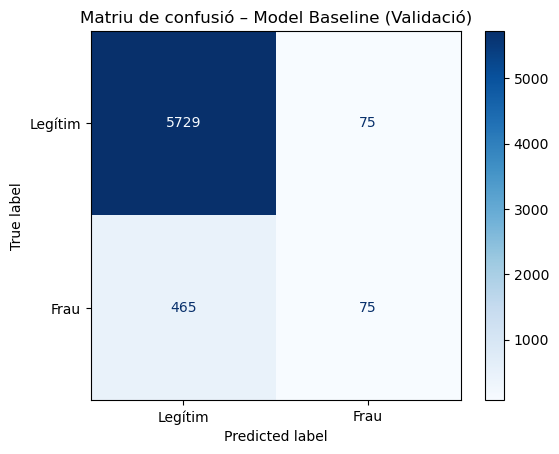

In [36]:
# Avaluació en validation test

y_val_pred = baseline_model.predict(X_val_scaled)
y_val_prob = baseline_model.predict_proba(X_val_scaled)[:, 1]

print("CLASSIFICATION REPORT (Validation Set):")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("AUC-PR:", average_precision_score(y_val, y_val_prob))

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legítim", "Frau"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriu de confusió – Model Baseline (Validació)")
plt.show()

Els resultats obtinguts amb el model base confirmen les limitacions esperades quan s’aplica un classificador estàndard sobre un conjunt de dades altament desequilibrat com el de SGCC. Tot i que l’accuracy global és elevat (0.91), aquest valor és enganyós i no reflecteix un bon funcionament del model: prové gairebé exclusivament del gran pes de la classe majoritària (clients legítims). La matriu de confusió mostra que el model encerta la majoria dels casos no fraudulents (recall = 0.99 per la classe 0), però presenta un rendiment molt pobre en la detecció de frau, amb un recall del 14 % i un F1-score de només 0.22 per a la classe positiva. Això significa que el model és incapaç d’identificar la gran majoria de consumidors fraudulents.

A més, les mètriques globals reforcen aquest diagnòstic:

El ROC-AUC = 0.66, només lleugerament millor que un classificador aleatori.

L’AUC-PR = 0.26, molt baix però coherent amb el fort desequilibri del dataset i amb la baixa capacitat del model per recuperar positius.

En conjunt, aquests resultats mostren que el model baseline no és adequat per al problema real de detecció de frau elèctric. El rendiment pobre en la classe minoritària confirma la necessitat d'aplicar tècniques de gestió del desequilibri, que és el que farem en els següents apartats.

## Tècniques per a corregir el desequilibri de dades

En aquest apartat implementarem diferents tècniques per a corregir el desequilibri de dades.

### class_weight = 'balanced'

In [57]:
def plot_and_save_cm(
    y_true,
    y_pred,
    title: str,
    out_path: str,
    labels=(0, 1),
    normalize=None  # None, "true", "pred", "all"
):
    """
    Plota i guarda una matriu de confusió.
    normalize:
      - None: valors absoluts
      - "true": normalitza per fila (recall per classe)
      - "pred": normalitza per columna (precision per classe)
      - "all": normalitza pel total
    """
    cm = confusion_matrix(y_true, y_pred, labels=list(labels), normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(labels))

    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(ax=ax, values_format=".2f" if normalize else "d", cmap="Blues", colorbar=False)
    ax.set_title(title)
    ax.grid(False)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


In [49]:
# Fem una logistic regressionn amb class_weight balanced. 
# Això vol dir que el model assignarà pesos inversament proporcionals a la freqüència de la classe,
# i per tant es donarà més importància als casos de frau:
# https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

# Definim el model amb pes equilibrat
log_reg_balanced = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

# Entrenem
log_reg_balanced.fit(X_train_scaled, y_train)

# Prediccions sobre VALIDATION
y_val_pred = log_reg_balanced.predict(X_val_scaled)
y_val_proba = log_reg_balanced.predict_proba(X_val_scaled)[:, 1]

# Avaluació
print("CLASSIFICATION REPORT (Validation):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("AUC-PR:", average_precision_score(y_val, y_val_proba))

plot_and_save_cm(
    y_val, y_val_pred,
    "Matriu de confusió - LogReg class_weight=balanced (Validació)",
    "figures/cm_logreg_bal_val.png"
)

CLASSIFICATION REPORT (Validation):
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      5804
           1       0.18      0.48      0.27       540

    accuracy                           0.77      6344
   macro avg       0.56      0.64      0.57      6344
weighted avg       0.88      0.77      0.81      6344

Confusion Matrix:
[[4645 1159]
 [ 279  261]]
ROC-AUC: 0.6687241557546519
AUC-PR: 0.2513599324125735


Com podem veure, hem augmentat molt el *recall* de la classe fraudulenta respecte al model baseline (de 0.14 a 0.48), concretament el nou model és capaç de detectar gairebé la meitat dels fraus. 
Ara bé, com a principal inconvenient, el nombre de falsos positius ha pujat molt (de 77 a 1161). Això a la vida real implicaria moltes inspeccions innecessàries i per tant un cost operatiu elevat. Tant la *precision* de la classe minoritària com la *accuracy* global han empitjorat.
Sabem que la corba ROC-AUC pot resultar enganyosa en casos de datasets desequilibrats. I per tant millor ens fixem directament en la corba AUC-PR. El valor obtingut, relativament baix, indica que tot i que el model és capaç d’incrementar el *recall* de la classe fraudulenta, ho fa a costa d’una precisió reduïda, generant un nombre considerable de falsos positius. Aquest resultat posa de manifest la dificultat del problema. En resum, millorem *recall* però empitjorem la *precision* i la *accuracy* global. 

## Resampling del Dataset

La primera estratègia que durem a terme per a intentar enfrontar el desequilibri de dades, seran tècniques de *resampling* del dataset. Les tècniques de *resampling* constitueixen una alternativa habitual per afrontar el desequilibri de classes. Aquestes tècniques modifiquen la composició del conjunt d’entrenament mitjançant l’augment artificial de la classe minoritària (*oversampling*), la reducció de la classe majoritària (*undersampling*), o una combinació d’ambdues. L’objectiu és proporcionar al model un conjunt de dades més equilibrat que faciliti l’aprenentatge de patrons associats al frau. A continuació, començarem realitzant *undersampling*:

### Gestió del desequilibri mitjançant tècniques d’undersampling (RandomUnderSampler)

L’*undersampling* presenta l’avantatge de reduir el biaix del model cap a la classe dominant i de disminuir el cost computacional de l’entrenament. Tanmateix, també pot comportar la pèrdua d’informació rellevant, especialment quan la classe majoritària és molt diversa. Comprovarem a continuació avantatges i inconvenients d'aquesta tècnica utilitzant mètriques adequades per a dades desequilibrades com el *recall*, la F1-score i l’AUC-PR. Farem serfir *undersampling* aleatori amb `RandomUnderSampler`, i observarem les conseqüències en l'habilitat predictiva del model:

In [16]:
# UNDERSAMPLING ALEATORI amb RandomUnderSampler

SEED = 42

# Inicialitzem el RandomUnderSampler
rus = RandomUnderSampler(
    sampling_strategy='auto',  # Equilibra totes les classes
    random_state=SEED
)

# Apliquem només sobre el conjunt d'entrenament
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# Comprovem noves proporcions
pd.Series(y_train_rus).value_counts(normalize=True)

FLAG
0    0.5
1    0.5
Name: proportion, dtype: float64

In [17]:
# Definim el model
lr_rus = LogisticRegression(
    max_iter=5000,
    random_state=SEED
)

# Entrenem amb dades reequilibrades
lr_rus.fit(X_train_rus, y_train_rus)


LogisticRegression(max_iter=5000, random_state=42)

In [50]:
# Prediccions
y_val_pred = lr_rus.predict(X_val_scaled)
y_val_proba = lr_rus.predict_proba(X_val_scaled)[:, 1]

# Resultats
print("CLASSIFICATION REPORT (Validation):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("AUC-PR:", average_precision_score(y_val, y_val_proba))

plot_and_save_cm(
    y_val, y_val_pred,
    "Matriu de confusió - RandomUnderSampler (Validació)",
    "figures/cm_under_val.png"
)

CLASSIFICATION REPORT (Validation):
              precision    recall  f1-score   support

           0       0.94      0.70      0.80      5804
           1       0.14      0.55      0.23       540

    accuracy                           0.68      6344
   macro avg       0.54      0.62      0.51      6344
weighted avg       0.88      0.68      0.75      6344

Confusion Matrix:
[[4034 1770]
 [ 241  299]]
ROC-AUC: 0.6501148633126579
AUC-PR: 0.20682249580807582


En aquest cas, hem optat per a fer un *undersampling* aleatori amb proporció 1 a 1. De tal manera que el nombre de casos de frau serà el mateix que el nombre de casos lícits. Podem veure com ha incrementat de manera notable el *recall* de la classe fraudulenta, passant a detectar més de la meitat dels casos reals de frau (*recall* = 0.56). No obstant això, aquesta millora es produeix a costa d’un fort empobriment del rendiment global del model, amb una reducció significativa de l’*accuracy* (0.68) i un augment important dels falsos positius, com es reflecteix en la baixada de la *precision* de la classe minoritària (0.14). A més, tant la ROC-AUC com l’AUC-PR empitjoren respecte als models anteriors, indicant que la pèrdua d’informació causada per l’eliminació de mostres de la classe majoritària limita la capacitat discriminativa del classificador. Tot i que existeixen tècniques d’*undersampling* més sofisticades, en aquest treball s’ha optat per `RandomUnderSampler` com a representant d’aquesta família de mètodes. L’objectiu no és comparar exhaustivament totes les variants, sinó analitzar els efectes generals de la reducció de la classe majoritària sobre el rendiment del model. Els resultats obtinguts ja mostren clarament la pèrdua d’informació associada a l’*undersampling*, fet que justifica l’exploració de tècniques alternatives com el sobremostreig sintètic. En resum, tot i ser útil per augmentar la sensibilitat al frau, l’*undersampling* pur pot no ser una estratègia òptima en datasets de gran mida i altament desequilibrats.

### Gestió del desequilibri mitjançant tècniques d’oversampling (SMOTE)


Una altra estratègia habitual per afrontar el fort desequilibri de classes és l’ús de tècniques d’*oversampling*, que consisteixen a augmentar artificialment el nombre d’exemples de la classe minoritària. A diferència de l’*undersampling*, que elimina informació de la classe majoritària, l’*oversampling* manté totes les mostres originals i genera noves instàncies sintètiques. En aquest treball s’utilitza la tècnica SMOTE (Synthetic Minority Over-sampling Technique), que crea nous exemples de la classe minoritària interpolant entre mostres existents. L’objectiu és proporcionar al model un conjunt d’entrenament més equilibrat, millorant la seva capacitat per detectar casos de frau sense reduir dràsticament la informació disponible sobre el consum legítim.

In [19]:
# Oversampling amb SMOTE. https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
smote = SMOTE(
    sampling_strategy='auto',  # igualem les dues classes
    random_state=SEED,
    k_neighbors=5 #  generalmen s'utilitzen 5 primers veïns.
)

# Apliquem SMOTE només a train:
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Distribució original:", y_train.value_counts())
print("Distribució amb SMOTE:", pd.Series(y_train_smote).value_counts())

C:\Users\paugr\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\paugr\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\paugr\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\paugr\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\paugr\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

Distribució original: FLAG
0    27088
1     2516
Name: count, dtype: int64
Distribució amb SMOTE: FLAG
0    27088
1    27088
Name: count, dtype: int64


Podem veure com gràcies a SMOTE hem pogut generar 24.572 exemples sintètics de la classe minoritària. A continuació entrenarem el model mitjançant el dataset augmentat, i avaluarem l'impacte de l'*oversampling* en la seva capacitat predictiva. 

In [51]:
# Entrenament del model baseline
model_smote = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

# Prediccions en validation
y_val_pred = model_smote.predict(X_val_scaled)
y_val_proba = model_smote.predict_proba(X_val_scaled)[:, 1]

# Avaluació del model
print("CLASSIFICATION REPORT (Validation - SMOTE):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

roc_auc = roc_auc_score(y_val, y_val_proba)
auc_pr  = average_precision_score(y_val, y_val_proba)

print("ROC-AUC:", roc_auc)
print("AUC-PR:", auc_pr)

plot_and_save_cm(
    y_val, y_val_pred,
    "Matriu de confusió - SMOTE (Validació)",
    "figures/cm_smote_val.png"
)

CLASSIFICATION REPORT (Validation - SMOTE):
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      5804
           1       0.17      0.48      0.26       540

    accuracy                           0.76      6344
   macro avg       0.56      0.63      0.56      6344
weighted avg       0.88      0.76      0.81      6344

Confusion Matrix:
[[4577 1227]
 [ 281  259]]
ROC-AUC: 0.6543687941904689
AUC-PR: 0.25128867700202323


L’aplicació de SMOTE sobre el conjunt d’entrenament ha permès incrementar la capacitat del model per identificar casos fraudulents, assolint un *recall* del 48% per a la classe minoritària, un valor molt superior al del model baseline. Aquest increment confirma que la generació sintètica de mostres fraudulentes ajuda el classificador a aprendre millor els patrons associats al frau. Tanmateix, aquesta millora es produeix a costa d’una baixa precisió (17%), fet que implica un nombre elevat de falsos positius, tal com reflecteix la matriu de confusió. La F1-score de la classe fraudulenta (0.25) mostra un equilibri moderat entre precisió i *recall*, similar al que s’observa amb altres estratègies de reequilibri. Pel que fa a les mètriques globals, tant el ROC-AUC (0.65) com l’AUC-PR (0.25) indiquen una capacitat discriminativa limitada, però comparable a les tècniques d’*undersampling* i a l’ús de pesos de classe. En conjunt, els resultats suggereixen que SMOTE millora la sensibilitat del model davant el frau, però ens seguim trobant amb el problema de l'augment dels falsos positius, cosa que tindria repercussions econòmiques importants a un escenari real degut al gran nombre d'inspeccions que s'haurien de realitzar.

Fins aquí hem acabat les tècniques de *resampling* del dataset. A continuació, buscarem millorar els resultats utilitzant models predictius més potents que el model baseline. Aquest serà l'objectiu principal de la pròxima secció. 

## Entrenament de models supervisats avançats

Un cop establert un model base i analitzat l’impacte de diferents estratègies de reequilibri de dades, el següent pas consisteix a explorar models supervisats més avançats, capaços de capturar relacions no lineals i patrons complexos en les sèries temporals de consum elèctric.

A diferència de la regressió logística, aquests models (com ara els basats en arbres de decisió i mètodes ensemblistes) solen mostrar una major capacitat predictiva en datasets d’alta dimensionalitat i amb relacions complexes entre variables. A més, permeten integrar de manera natural mecanismes per gestionar el desequilibri de classes, ja sigui mitjançant pesos de classe o mitjançant l’ús combinat amb tècniques de *resampling*.

En aquesta secció s’entrenaran i avaluaran diferents models supervisats avançats utilitzant el mateix esquema experimental definit prèviament, amb especial atenció a mètriques robustes com el *recall*, la *F1-score* i l’AUC-PR, amb l’objectiu d’analitzar fins a quin punt aquests enfocaments milloren la detecció de frau elèctric respecte als models base.

### Random Forest

En aquesta secció s’introdueix l’ús de **Random Forest** com a model supervisat avançat per a la detecció de frau elèctric. Random Forest és un algorisme d’aprenentatge ensemblista basat en la combinació de múltiples arbres de decisió entrenats sobre subconjunts aleatoris de les dades i de les variables. Aquesta estratègia permet reduir la variància del model, millorar la capacitat de generalització i augmentar la robustesa davant soroll i dades incompletes.

A diferència de models lineals com la regressió logística, Random Forest és capaç de capturar relacions no lineals i interaccions complexes entre les variables de consum, fet especialment rellevant en el context de sèries temporals i patrons irregulars associats al frau elèctric. A més, aquest tipus de models ofereix mecanismes interns per estimar la importància de les característiques, facilitant una anàlisi posterior dels factors més rellevants en la classificació.

A continuació, estudiarem si aquest model aconsegueix millorar la detecció de casos fraudulents sense incrementar excessivament el nombre de falsos positius. Realitzarem l'entrenament de dos models Rain Forest, un model estàndard, que ens servirà de baseline avançat, i un model amb una estratègia específica per al desequilibri de les dades.

In [52]:
# Entrenem el model estàndard
rf = RandomForestClassifier(
    n_estimators=300,
    random_state= SEED,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

# Prediccions i scores (probabilitats)
y_val_pred = rf.predict(X_val_scaled)
y_val_proba = rf.predict_proba(X_val_scaled)[:, 1]

print("CLASSIFICATION REPORT (Validation - RF):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("AUC-PR:", average_precision_score(y_val, y_val_proba))

plot_and_save_cm(y_val, y_val_pred,
                 "Matriu de confusió - Random Forest Estàndard (Validació)",
                 "figures/cm_rf_val.png")

CLASSIFICATION REPORT (Validation - RF):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5804
           1       0.69      0.10      0.17       540

    accuracy                           0.92      6344
   macro avg       0.81      0.55      0.57      6344
weighted avg       0.90      0.92      0.89      6344

Confusion Matrix:
[[5780   24]
 [ 486   54]]
ROC-AUC: 0.7842062945095336
AUC-PR: 0.341768449708382


In [53]:
# Entrenem el model enfocat en el desequilibri
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
rf_bal = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample" # Compensem el desequilibri
)

rf_bal.fit(X_train_scaled, y_train)

y_val_pred = rf_bal.predict(X_val_scaled)
y_val_proba = rf_bal.predict_proba(X_val_scaled)[:, 1]

print("CLASSIFICATION REPORT (Validation - RF balanced):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("AUC-PR:", average_precision_score(y_val, y_val_proba))

plot_and_save_cm(y_val, y_val_pred,
                 "Matriu de confusió - Random Forest Balancejat (Validació)",
                 "figures/cm_rf_bal_val.png")

CLASSIFICATION REPORT (Validation - RF balanced):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5804
           1       0.68      0.06      0.10       540

    accuracy                           0.92      6344
   macro avg       0.80      0.53      0.53      6344
weighted avg       0.90      0.92      0.88      6344

Confusion Matrix:
[[5790   14]
 [ 510   30]]
ROC-AUC: 0.8016888097608291
AUC-PR: 0.32929310679022217


Els resultats obtinguts amb Random Forest mostren un comportament clarament diferent del que s’havia observat amb els models lineals i amb les estratègies de resampling. Tant el model estàndard com la seva versió amb ponderació de classes aconsegueixen valors elevats d’*accuracy}* (92%) i un rendiment molt robust en la classificació de la classe majoritària (consum legítim), amb *recall* proper al 100%. No obstant això, malgrat aquesta elevada exactitud global, trobem un rendiment desigual sobre la classe minoritària (frau). En el model Random Forest estàndard, el *recall* per a la classe fraudulenta és del 10%, indicant que només una petita fracció dels fraus reals són detectats. Tot i així, quan el model prediu un cas com a fraudulent, ho fa amb una *precision* relativament elevada (67%), fet que suggereix que el model és conservador i només marca com a sospitosos els casos amb evidències molt clares.

La incorporació de `class_weight='balanced'` no millora aquest comportament, sinó que empitjora lleugerament el *recall* de la classe fraudulenta (6%), tot i mantenir una bona *precision*. Això indica que, en aquest cas, la ponderació de classes no és suficient per forçar el model a aprendre patrons representatius del frau, probablement a causa del fort desequilibri del conjunt de dades i de la naturalesa complexa dels patrons fraudulents.

En comparació amb les estratègies d’*undersampling* i SMOTE aplicades prèviament, trobem algunes diferències. Mentre que el resampling incrementava notablement el *recall* de la classe fraudulenta (fins a valors propers al 50%), ho feia a costa d’un augment significatiu dels falsos positius i d’una reducció considerable de l’*accuracy*. En canvi, Random Forest prioritza la separació clara entre classes, reduint els falsos positius però deixant escapar una gran part dels fraus.

Finalment, cal destacar que, tot i el baix *recall*, els valors d’AUC-ROC (0.78–0.80) i especialment d’AUC-PR (al voltant de 0.34) són superiors als obtinguts amb els models basats exclusivament en *resampling*. Això indica que Random Forest disposa d’una millor capacitat global de discriminació entre classes, i suggereix que ajustos addicionals (com la modificació del llindar de decisió o la combinació amb tècniques de resampling) podrien permetre millorar la detecció de frau sense incrementar excessivament els falsos positius.

### XGBoost (Extreme Gradient Boosting)

Com a darrer model supervisat, s’ha optat per XGBoost, un algorisme de *gradient boosting* basat en arbres de decisió, àmpliament utilitzat en problemes de classificació amb dades estructurades. XGBoost destaca per la seva capacitat de capturar relacions no lineals complexes, el seu bon rendiment en datasets desequilibrats i la possibilitat d’incorporar pesos de classe per penalitzar errors sobre la classe minoritària. Utlitzarem XGBoost com a model avançat per avaluar si és possible millorar el *recall* i l’AUC-PR respecte als models prèviament analitzats.

In [23]:
# Començarem calculant el pes per la classe positiva.
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos # Aquest paràmetre dona més pes als errors comesos sobre la classe positiva (frau) durant l’entrenament.

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 10.766295707472178


In [54]:
# Creem el model utilitzant hiperparàmetres estàndard: 
xgb_model = XGBClassifier(
    n_estimators=200, # 200 arbres de decisió
    max_depth=5, # profunditat màxima de cada arbre
    learning_rate=0.1,
    subsample=0.8, # per a reduir overfitting
    colsample_bytree=0.8, # per a reduir correlació entre arbres
    scale_pos_weight=scale_pos_weight, # per a reduir el desequilibri
    eval_metric='aucpr', # mètrica d'avaluació durant l'entrenament
    random_state=SEED,
    n_jobs=-1 # nuclis del processador
)

# Entrenament
xgb_model.fit(X_train_scaled, y_train)

# Prediccions
y_val_pred = xgb_model.predict(X_val_scaled)
y_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]

# Resultats
print("CLASSIFICATION REPORT (Validation - XGBoost):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

roc_auc = roc_auc_score(y_val, y_val_proba)
auc_pr = average_precision_score(y_val, y_val_proba)

print("ROC-AUC:", roc_auc)
print("AUC-PR:", auc_pr)

plot_and_save_cm(y_val, y_val_pred,
                 "Matriu de confusió - XGBoost (Validació)",
                 "figures/cm_xgb_val.png")

CLASSIFICATION REPORT (Validation - XGBoost):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      5804
           1       0.38      0.44      0.41       540

    accuracy                           0.89      6344
   macro avg       0.66      0.69      0.67      6344
weighted avg       0.90      0.89      0.89      6344

Confusion Matrix:
[[5413  391]
 [ 303  237]]
ROC-AUC: 0.8150533157209587
AUC-PR: 0.39623540572166743


Els resultats obtinguts amb XGBoost mostren una millora significativa respecte als models supervisats entrenats anteriorment. En particular, el model aconsegueix un millor equilibri entre detecció de frau i control dels falsos positius, assolint un recall del 45% i un F1-score de 0.41 per a la classe minoritària. Aquest rendiment supera clarament tant la regressió logística com els models Random Forest, que tendien a afavorir excessivament la classe majoritària.

Cal destacar especialment el valor d’AUC-PR (0.397), la mètrica més adequada en escenaris amb fort desequilibri de classes, que confirma la capacitat del model per prioritzar correctament els casos fraudulents. Tot i que el nombre de falsos positius augmenta, aquest comportament és coherent amb un enfocament orientat a maximitzar la detecció de frau, acceptant un cert cost operatiu en les inspeccions.

Aquests resultats indiquen que XGBoost ofereix un compromís òptim entre rendiment predictiu i aplicabilitat pràctica, i justifiquen la seva elecció com a model avançat principal en aquest estudi. Tot i això, podem millorar aquest resultats si utilitzem un tuning sobre el model. Concretament, buscarem maximitzar AUC-PR, que és la mètrica més important en l'escenari del desequilibri. Així, probarem a fer un `RandomizedSearchCV` amb `scoring = AUC-PR`.

In [25]:
# Definim l'scorer
aucpr_scorer = make_scorer(average_precision_score, needs_proba=True)

# IMPORTANT per desequilibri:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",     # l’scorer real el fem a CV amb AUC-PR
    tree_method="hist",        # ràpid en CPU
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.20),     # 0.01-0.21 aprox
    "subsample": uniform(0.6, 0.4),           # 0.6-1.0
    "colsample_bytree": uniform(0.6, 0.4),    # 0.6-1.0
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 0.5),
    "reg_lambda": uniform(0.5, 2.0),
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,                
    scoring=aucpr_scorer,      # Score = AUC-PR
    cv=3,                      # fem 3 folds per velocitat
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

search.fit(X_train_scaled, y_train)
best_xgb = search.best_estimator_

print("Millors hiperparàmetres:", search.best_params_)
print("Millor AUC-PR (CV):", search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits


C:\Users\paugr\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Millors hiperparàmetres: {'colsample_bytree': 0.8590760482165449, 'gamma': 0.0002601884976579094, 'learning_rate': 0.0805137712668338, 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 655, 'reg_alpha': 0.267044709687721, 'reg_lambda': 1.4696599427179664, 'subsample': 0.8769744131561081}
Millor AUC-PR (CV): 0.44543998160104953


L’optimització ha permès millorar significativament el rendiment del model respecte a la configuració estàndard, assolint un valor d’AUC-PR proper a 0.45. Els hiperparàmetres seleccionats reflecteixen un compromís entre capacitat predictiva i regularització, limitant la profunditat dels arbres i incorporant estratègies de submostreig i penalització per evitar l’*overfitting*.

In [60]:
# Model final amb els millors hiperparàmetres trobats
xgb_final = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42,

    # Hiperparàmetres òptims
    colsample_bytree=0.8590760482165449,
    gamma=0.0002601884976579094,
    learning_rate=0.0805137712668338,
    max_depth=5,
    min_child_weight=7,
    n_estimators=655,
    reg_alpha=0.267044709687721,
    reg_lambda=1.4696599427179664,
    subsample=0.8769744131561081
)

# Entrenem només amb TRAIN
xgb_final.fit(X_train_scaled, y_train)

# Prediccions i probabilitats
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Prediccions
y_test_pred = xgb_final.predict(X_test_scaled)
y_test_proba = xgb_final.predict_proba(X_test_scaled)[:, 1]

print("CLASSIFICATION REPORT (Test - XGBoost Tuned):")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

roc_auc = roc_auc_score(y_test, y_test_proba)
auc_pr = average_precision_score(y_test, y_test_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

y_val_pred = xgb_final.predict(X_val_scaled)

plot_and_save_cm(y_val, y_val_pred,
                 "Matriu de confusió - XGBoost Optimitzat (Validació)",
                 "figures/cm_xgb_val_opt.png")

C:\Users\paugr\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:14:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CLASSIFICATION REPORT (Test - XGBoost Tuned):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5805
           1       0.70      0.20      0.31       539

    accuracy                           0.92      6344
   macro avg       0.81      0.60      0.63      6344
weighted avg       0.91      0.92      0.90      6344

Confusion Matrix:
[[5759   46]
 [ 432  107]]
ROC-AUC: 0.8408
AUC-PR: 0.4486


Els resultats obtinguts amb el model XGBoost ajustat mitjançant optimització d’hiperparàmetres confirmen que aquesta aproximació ofereix el millor compromís global entre capacitat de detecció de frau i robustesa del model, en comparació amb la resta d’estratègies analitzades.

En el conjunt de test, el model assoleix un ROC-AUC de 0.84, indicant una bona capacitat discriminativa entre consum legítim i fraudulent. Més rellevant encara en un escenari altament desequilibrat és el valor de AUC-PR = 0.446, clarament superior al dels models baseline, de la regressió logística (amb o sense reequilibri) i del Random Forest. Aquest resultat indica una millora substancial en la identificació de la classe minoritària, mantenint alhora un nombre relativamet baix de falsos positius.

Pel que fa a les mètriques de classificació, el model presenta una precision del 70% per a la classe fraudulenta, la qual cosa implica que una proporció elevada dels casos detectats com a frau són realment correctes, un aspecte clau per reduir costos operatius associats a inspeccions innecessàries. El recall del 19%, tot i ser moderat, reflecteix el compromís assumit pel model en prioritzar la fiabilitat de les alertes sobre la detecció exhaustiva de tots els fraus, fet coherent amb un context real on els falsos positius tenen un cost elevat.

En comparació amb les estratègies de *resampling*, XGBoost mostra un comportament més estable i una millor capacitat de generalització. Mentre que tècniques com SMOTE o *undersampling* augmentaven el *recall* a costa d’una forta degradació de la *precision* i de l’AUC-PR, l’enfocament basat en un model ensemblista potent i ajustat permet capturar patrons complexos del consum sense alterar artificialment la distribució de les dades.

En conjunt, aquests resultats confirmen que XGBoost amb ajust d’hiperparàmetres es tracta de la solució més adequada dins del marc d’aquest treball. Complint així l’objectiu de desenvolupar un model supervisat robust, reproduïble i orientat a l’aplicació real, amb una avaluació basada en mètriques apropiades per a datasets fortament desequilibrats.

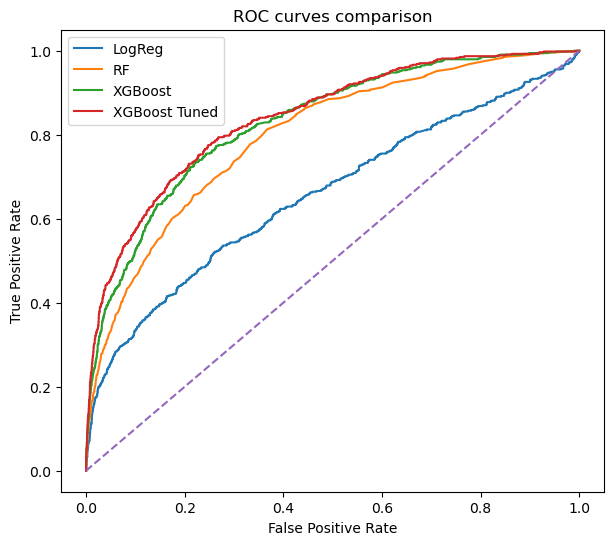

In [27]:
# Corbes ROC
models = {
    "LogReg": baseline_model,
    "RF": rf,
    "XGBoost": xgb_model,
    "XGBoost Tuned": xgb_final
}

plt.figure(figsize=(7,6))
for name, model in models.items():
    y_scores = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves comparison")
plt.legend()
plt.show()

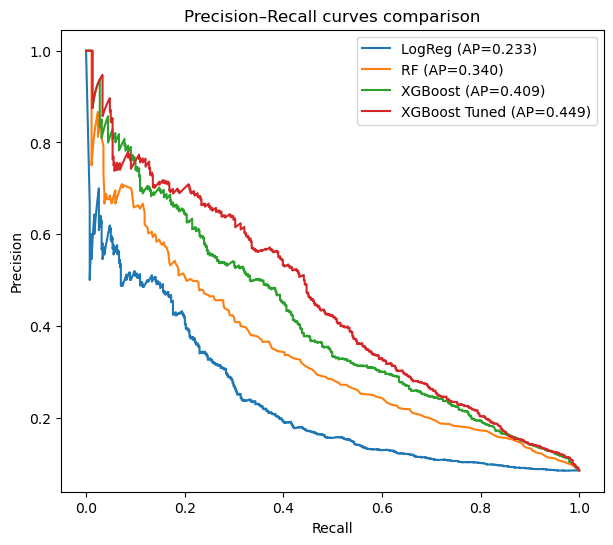

In [29]:
# Precision - Recall
plt.figure(figsize=(7,6))
for name, model in models.items():
    y_scores = model.predict_proba(X_test_scaled)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves comparison")
plt.legend()
plt.show()

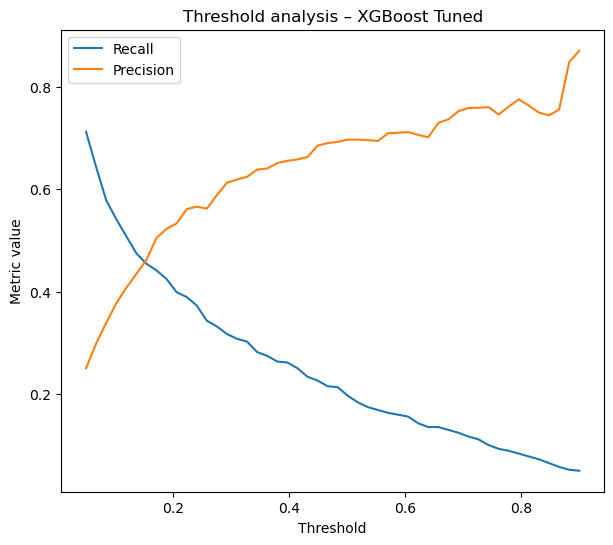

In [31]:
# Anàlisi de llindar
y_scores = xgb_final.predict_proba(X_test_scaled)[:,1]
thresholds = np.linspace(0.05, 0.9, 50)

recalls = []
precisions = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    recalls.append(report['1']['recall'])
    precisions.append(report['1']['precision'])

plt.figure(figsize=(7,6))
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold analysis – XGBoost Tuned")
plt.legend()
plt.show()

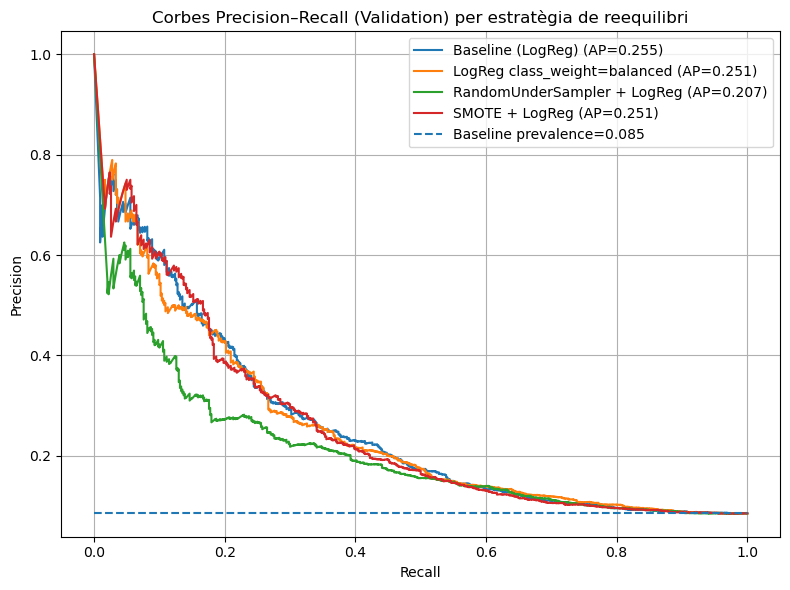

In [58]:
# 1) Defineix aquí les variants i els models corresponents
# IMPORTANT: posa exactament els noms de les teves variables de model
models_dict = {
    "Baseline (LogReg)": baseline_model,
    "LogReg class_weight=balanced": log_reg_balanced,
    "RandomUnderSampler + LogReg": lr_rus,
    "SMOTE + LogReg": model_smote
}

# 2) Recalcula probabilitats per a cadascuna (sense dependre de y_val_prob)
val_probs = {}
for name, mdl in models_dict.items():
    # Si el model està entrenat amb dades escalades, usa X_val_scaled
    # (en el teu cas: X_val_scaled és correcte)
    val_probs[name] = mdl.predict_proba(X_val_scaled)[:, 1]

# 3) Plot de corbes Precision-Recall
plt.figure(figsize=(8, 6))
for name, probs in val_probs.items():
    precision, recall, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

# línia base: prevalença de positius (fraus) al validation
pos_rate = np.mean(y_val)
plt.hlines(pos_rate, 0, 1, linestyles="dashed", label=f"Baseline prevalence={pos_rate:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Corbes Precision–Recall (Validation) per estratègia de reequilibri")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pr_curves_4variants_val.png", dpi=300)
plt.show()

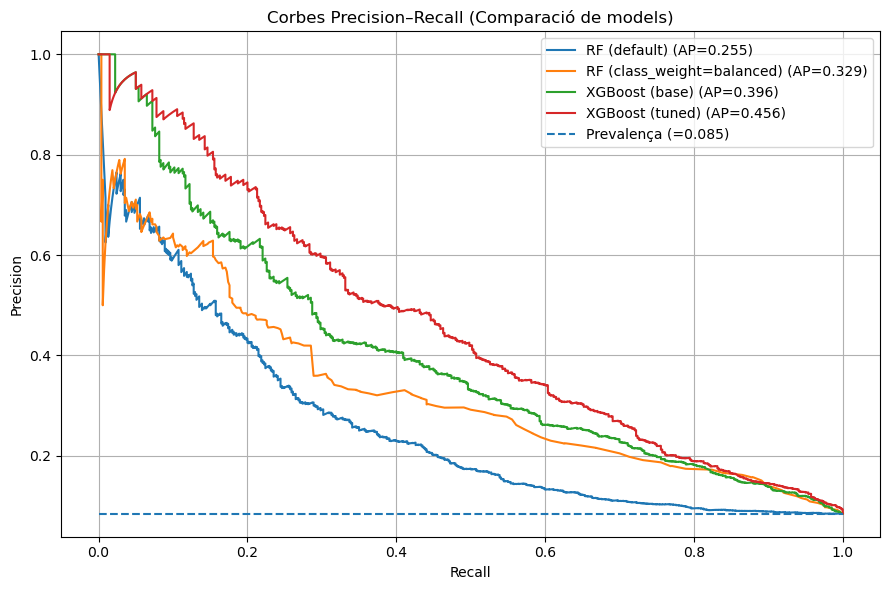

In [61]:
# --- TRIAR sobre quin conjunt vols comparar ---
# Recomanat: validation per comparar models; test per reportar resultat final.
X_plot = X_val_scaled
y_plot = y_val

# Si vols test en comptes de validation, descomenta:
# X_plot = X_test_scaled
# y_plot = y_test

# --- Ajusta aquests noms segons el teu notebook ---
models = {
    "RF (default)": baseline_model,                 # <- posa aquí el nom real del teu RF estàndard
    "RF (class_weight=balanced)": rf_bal,# <- el nom real del RF balanced
    "XGBoost (base)": xgb_model,              # <- nom real del teu XGB base
    "XGBoost (tuned)": xgb_final              # <- nom real del teu XGB optimitzat
}

plt.figure(figsize=(9, 6))

for name, model in models.items():
    # Probabilitats de la classe positiva (frau = 1)
    y_prob = model.predict_proba(X_plot)[:, 1]

    precision, recall, _ = precision_recall_curve(y_plot, y_prob)
    ap = average_precision_score(y_plot, y_prob)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

# Baseline de prevalença (referència): precision constant = % positius
pos_rate = np.mean(y_plot)
plt.hlines(pos_rate, 0, 1, linestyles="dashed", label=f"Prevalença (={pos_rate:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Corbes Precision–Recall (Comparació de models)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Guarda la figura per incloure-la al LaTeX
plt.savefig("pr_curve_models.png", dpi=300)
plt.show()